# End-to-end CNN Training Example

This notebook illustrates how to use PyEarthTools pipeline to train a simple machine learning Convolutional Neural Network (CNN) model using the [WeatherBench2 ERA5](https://weatherbench2.readthedocs.io/en/latest/data-guide.html#era5) dataset.

The general aim of this machine learning project is to predict the future state of the atmosphere by taking the current, or previous state and predicting a number of hours ahead in time.

We will select specific ERA5 variables in our `data_pipeline` however, feel free to experiment by changing these.

* **Model input data**: We will use a range of specific ERA5 variables at T+0hr as our input features. 
* **Model target data**: We will try and predict these variables at T+6hrs ahead (try changing this to predict further ahead). 

## Import packages and set parameters

In [1]:
import sys
from pathlib import Path

import numpy as np
import xarray as xr
import scores
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from lightning import Trainer, LightningModule
from lightning.pytorch.callbacks import RichProgressBar
from rich.progress import track

import pyearthtools.data
import pyearthtools.tutorial
import pyearthtools.pipeline
import pyearthtools.training

In [2]:
# training data split
train_start = "2013-01-01T00"
train_end = "2015-01-12T00"

# Validation data uses the same dates and time, but 1 year after the training data. 
val_start = "2016-01-01T00"
val_end = "2016-01-12T00"

# Test data uses the same dates and time, but 2 years after the training data. 
test_start = "2017-01-01T00"
test_end = "2017-01-12T00"

# number of samples to estimate mean & standard deviation of fields
n_samples = 200

# data loader parameters
batch_size = 1
n_workers = 2

# trainer parameters
max_epochs = 10

# folder to download data and cache intermediate results
workdir = Path("cnn_training")

## Data Preparation Pipeline

Pipelines can be created with a single call to `pyearthtools.pipeline.Pipeline`. When we make a call to a Pipeline in a notebook the output is a tabular description of the pipeline, and a graphical ordered representation of the transformations described in the definition of the pipeline.

We will start by setting up a data preparation pipeline that can be used to display data using Xarray, then move on to modifying the pipeline to output numpy arrays.
It is useful to display the data structure using Xarray, as it provides a convenient HTML representation of the data.
This can help us understand the data format and structure before we convert it to NumPy for further processing

**Note:** this step isn't necessary for training, but it can be helpful for data exploration and verification.

### Explanation of Pipeline Steps

1. The data preparation step retrieves ERA5 data for the variables "2m_temperature", "u_component_of_wind", "v_component_of_wind", "geopotential" and "vorticity".
2. The data is sorted in the order of "2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity" and "geopotential".
3. The coordinates are standardized to the 0-360° longitude format.
4. The level coordinate is flattened.
5. The `TemporalRetrieval` operation retrieves data from reference time and 6 hours after the reference time:
   - Index 0 of the sample contains the input data at T+0hr, using the (0, 1) tuple.
   - Index 1 of the sample contains the output data at T+6hrs, using the (6, 1) tuple.

The input data is used by the model to make predictions, while the output data represents the true values that the model aims to predict.

Saving dataset, it will take at most 3.83 gigabytes of storage space.
macadamia - 2025-08-25 02:28:15,523 - pyearthtools.data.download.weatherbench - weatherbench - save_local_dataset - L123 - WARNING - Saving dataset, it will take at most 3.83 gigabytes of storage space.
Saving 2m_temperature variable under cnn_training/download/ee5f0931735d8d146214aa551175dfa34b3e33093aec3b93d20bcc78c56bcd1b/2m_temperature.zarr, it will take at most 766.31 megabytes of storage space.


Writing:   0%|          | 0/937 [00:00<?, ?it/s]

Saving 2m_temperature variable finished.
Saving geopotential variable (level 850) under cnn_training/download/ee5f0931735d8d146214aa551175dfa34b3e33093aec3b93d20bcc78c56bcd1b/geopotential_level-850.zarr, it will take at most 766.31 megabytes of storage space.


Writing:   0%|          | 0/2809 [00:00<?, ?it/s]

Saving geopotential variable (level 850) finished.
Saving u_component_of_wind variable (level 850) under cnn_training/download/ee5f0931735d8d146214aa551175dfa34b3e33093aec3b93d20bcc78c56bcd1b/u_component_of_wind_level-850.zarr, it will take at most 766.31 megabytes of storage space.


...

Saving u_component_of_wind variable (level 850) finished.
Saving v_component_of_wind variable (level 850) under cnn_training/download/ee5f0931735d8d146214aa551175dfa34b3e33093aec3b93d20bcc78c56bcd1b/v_component_of_wind_level-850.zarr, it will take at most 766.31 megabytes of storage space.


Writing:   0%|          | 0/2809 [00:00<?, ?it/s]

Saving v_component_of_wind variable (level 850) finished.
Saving vorticity variable (level 850) under cnn_training/download/ee5f0931735d8d146214aa551175dfa34b3e33093aec3b93d20bcc78c56bcd1b/vorticity_level-850.zarr, it will take at most 766.31 megabytes of storage space.


Writing:   0%|          | 0/2809 [00:00<?, ?it/s]

Saving vorticity variable (level 850) finished.


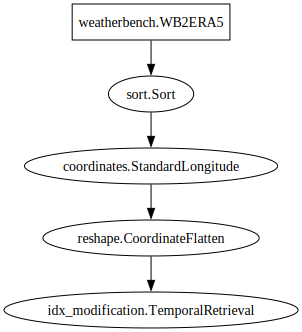

In [3]:
data_preparation = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
        level=[850],
        download_dir=workdir / "download",
        license_ok=True,
    ),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
    ),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    # retrieve previous/next samples, dt = 1H
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1))
    ),
)
data_preparation

### Using the pipeline

To make use of a pipeline object, we simply pass a datetime value to it.
This allows the pipeline to process and retrieve the relevant data for the specified datetime.

The `data_preparation` pipeline to return 2 elements for each datetime: input data at T+0hr and target data at T+6hrs.

In [4]:
input_sample, target_sample = data_preparation[train_start]
print("Train start:", train_start)
print("Input sample:", input_sample.time.data)
print("Target sample:", target_sample.time.data)

Train start: 2013-01-01T00
Input sample: ['2013-01-01T00:00:00.000000000']
Target sample: ['2013-01-01T06:00:00.000000000']


## Complete Pipeline

### NumPy Conversion

The following pipeline steps are similar to the previous ones but include additional steps for converting the data to NumPy. This conversion is necessary to prepare the data for ML training.

Additional steps are:

1. Export to a NumPy array.
2. Rearrange the axes of the NumPy array.
3. Remove dimensions of size 1 via a "squeeze" operation.

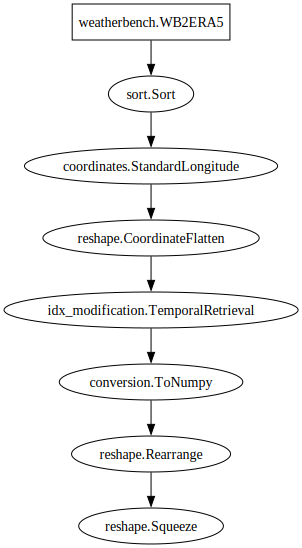

In [5]:
data_preparation = pyearthtools.pipeline.Pipeline(
    pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential", "vorticity"],
        level=[850],
        download_dir=workdir / "download",
        license_ok=True,
    ),
    pyearthtools.pipeline.operations.xarray.Sort(
        ["2m_temperature", "u_component_of_wind", "v_component_of_wind", "vorticity", "geopotential"]
    ),
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="0-360"),
    pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),
    # retrieve previous/next samples, dt = 1H
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 1), (6, 1))
    ),
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange("c t h w -> t c h w"),
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),
)
data_preparation

We can again provide a datetime to the pipeline to see how it retrieves and processes the corresponding data.<br>
Remember we can index on the sample data:

* [0] for input data 
* [1] for target data

In [6]:
# Create a sample by passing the data_preparation a datetime. 
sample = data_preparation[train_start]
print("Number of samples:", len(sample))
print("Input data shape:",  sample[0].shape)
print("Target data shape:",  sample[1].shape)

Number of samples: 2
Input data shape: (5, 64, 32)
Target data shape: (5, 64, 32)


### Train/test split

We need to split our data into **training**, **test** and **validation** splits. <br>
We can use the PyEathTools DateRange object to split our data. <br>
We can randomise our training data by chaining the `.randomise` method.

In [7]:
train_split = pyearthtools.pipeline.iterators.DateRange(train_start, train_end, interval="6h").randomise(seed=42)
train_split

Calculated indexes


DateRandomise
	Initialisation                 Wrap around another `Iterator` and randomly sample
		 iterator                       {'DateRange': {'allowlist': 'None', 'blocklist': 'None', 'end': "'2015-01-12T00'", 'interval': "'6h'", 'start': "'2013-01-01T00'"}}
		 seed                           42

Lets create another DataRange object for our validation split, but we don't need to randomise this data. 

In [8]:
val_split = pyearthtools.pipeline.iterators.DateRange(val_start, val_end, interval="6h")
val_split

DateRange
	Initialisation                 DateRange Iterator
		 allowlist                      None
		 blocklist                      None
		 end                            '2016-01-12T00'
		 interval                       '6h'
		 start                          '2016-01-01T00'

In [9]:
print("Train Splits:", train_split[:5])
print("Val Splits:  ", val_split[:5])

Train Splits: (Petdt('2013-04-11T12'), Petdt('2013-09-10T00'), Petdt('2014-03-19T00'), Petdt('2013-10-18T00'), Petdt('2013-04-16T00'))
Val Splits:   (Petdt('2016-01-01T00'), Petdt('2016-01-01T06'), Petdt('2016-01-01T12'), Petdt('2016-01-01T18'), Petdt('2016-01-02T00'))


### Data normalisation

We compute the mean and standard deviation of each field to rescale the input/output data to a reasonable range for model training.

In [10]:
%%time
samples = np.stack([data_preparation[i][0] for i in train_split])

mean_path = workdir / "mean.npy"
np.save(mean_path, np.mean(samples, axis=0))

std_path = workdir / "std.npy"
np.save(std_path, np.std(samples, axis=0))

CPU times: user 1min 56s, sys: 2.67 s, total: 1min 59s
Wall time: 2min 1s


In [11]:
# Initialise the normaliser with mean and standard deviation paths
normaliser = pyearthtools.pipeline.operations.numpy.normalisation.Deviation(
    mean=mean_path,
    deviation=std_path,
    expand=False
)

In [12]:
# Set up the caching mechanism to store processed data in the specified folder with .npy extension
caching_step = pyearthtools.pipeline.modifications.Cache(
    workdir / "cache", 
    pattern_kwargs={'extension': 'npy'},
    # cache_validity='delete'
)

In [13]:
# Initialise the data preparation pipeline with normalization and caching steps
data_preparation_normed = pyearthtools.pipeline.Pipeline(
    data_preparation,
    normaliser,
    caching_step
)

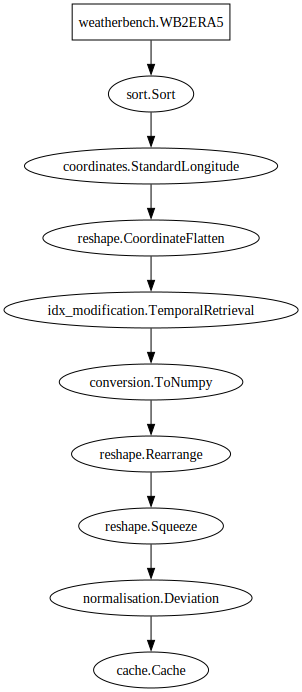

In [14]:
data_preparation_normed

## Model fitting

In [15]:
class CNN(LightningModule):
    def __init__(
        self,
        *,
        n_features: int,
        layer_sizes: list[int],
        dropout: float,
        learning_rate: float,
    ):
        super().__init__()
        self.save_hyperparameters()

        layer_sizes = (n_features,) + tuple(layer_sizes)
        layers = []
        for chan_in, chan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            layers.extend(
                [
                    nn.Conv2d(chan_in, chan_out, kernel_size=3, stride=1, padding=1),
                    nn.ReLU(),
                    nn.Dropout(p=dropout),
                ]
            )
        layers.append(
            nn.Conv2d(layer_sizes[-1], n_features, kernel_size=3, stride=1, padding=1)
        )
        self.cnn = nn.Sequential(*layers)

        self.learning_rate = learning_rate
        self.loss_function = F.l1_loss

    def forward(self, x):
        return self.cnn(x)

    def training_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs)
        loss = self.loss_function(outputs, targets)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, targets = batch
        outputs = self(inputs)
        loss = self.loss_function(outputs, targets)
        self.log("val_loss", loss)

    def predict_step(self, batch, batch_idx):
        # handle case when data comes from prediction pipeline
        if len(batch) == 2:
            return self(batch[0])
        return self(batch)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return {"optimizer": optimizer}

In [16]:
# Print the shape of the normalised training data for the given start date
print(data_preparation_normed[train_start][0].shape)

# Extract the number of features from the normalised training data
n_features = data_preparation_normed[train_start][0].shape[-3]
print(f"Number of features: {n_features}")

(5, 64, 32)
Number of features: 5


In [17]:
# Define the parameters for the CNN model
model_params = {
    'n_features': n_features,
    'layer_sizes': [64, 64],
    'dropout': 0.6,
    'learning_rate': 1e-5
}

# Initialise the CNN model with the specified parameters
model = CNN(**model_params)

In [18]:
model

CNN(
  (cnn): Sequential(
    (0): Conv2d(5, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): Dropout(p=0.6, inplace=False)
    (6): Conv2d(64, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [19]:
# Uncomment the following line to use the CPU even if a GPU is available.
#%env CUDA_VISIBLE_DEVICES=

## Integration With PyTorch Lightning

### The Lightning Data Module
The data module encapsulates all the data-related operations, including:

- **Data Preparation**: Applying the data preparation pipeline to preprocess the data.
- **Data Splitting**: Splitting the data into training and validation sets.
- **Batching**: Creating batches of data for training and validation.
- **Multiprocessing**: Handling data loading in parallel.

The data module integrates seamlessly with PyTorch Lightning, allowing the user to focus on defining their model and training logic without worrying about the data loading and preprocessing details. When one passes the data module to a PyTorch Lightning trainer, it automatically handles the data loading and batching during training and validation.

**Note:** Here we use `forkserver` to prevent deadlocks on Linux platform when using more than one worker in the data loader.



In [20]:
# Initialise the lightning data module for training
data_module = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    data_preparation_normed,    # Data preparation pipeline
    train_split=train_split,    # Training data split
    valid_split=val_split,      # Validation data split
    batch_size=batch_size,      # Batch size for training
    num_workers=n_workers,      
    multiprocessing_context="forkserver",  
    persistent_workers=True     # Keep workers alive between epochs
)

In [21]:
data_module

PipelineLightningDataModule
	Initialisation                 Pytorch Lightning DataModule.
		 batch_size                     1
		 iterator_dataset               False
		 multiprocessing_context        'forkserver'
		 num_workers                    2
		 persistent_workers             True
		 pipelines                      {'Pipeline': {'__args': '(Pipeline\n\tDescription                    `pyearthtools.pipeline` Data Pipeline\n\n\n\tInitialisation                 \n\t\t exceptions_to_ignore           None\n\t\t iterator                       None\n\t\t sampler                        None\n\tSteps                          \n\t\t weatherbench.WB2ERA5           {\'WB2ERA5\': {\'download_dir\': "PosixPath(\'cnn_training/download\')", \'level\': \'[850]\', \'license_ok\': \'True\', \'resolution\': "\'64x32\'", \'variables\': "[\'2m_temperature\', \'u\', \'v\', \'geopotential\', \'vorticity\']"}}\n\t\t sort.Sort                      {\'Sort\': {\'order\': "[\'2m_temperature\', \'u_component_of_wind\', \'v_component_of_wind\', \'vorticity\', \'geopotential\']", \'strict\': \'False\'}}\n\t\t coordinates.StandardLongitude  {\'StandardLongitude\': {\'longitude_name\': "\'longitude\'", \'type\': "\'0-360\'"}}\n\t\t reshape.CoordinateFlatten      {\'CoordinateFlatten\': {\'__args\': \'()\', \'coordinate\': "\'level\'", \'skip_missing\': \'False\'}}\n\t\t idx_modification.TemporalRetrieval {\'TemporalRetrieval\': {\'concat\': \'True\', \'delta_unit\': \'None\', \'merge_function\': \'None\', \'merge_kwargs\': \'None\', \'samples\': \'((0, 1), (6, 1))\'}}\n\t\t conversion.ToNumpy             {\'ToNumpy\': {\'reference_dataset\': \'None\', \'run_parallel\': \'False\', \'saved_records\': \'None\', \'warn\': \'True\'}}\n\t\t reshape.Rearrange              {\'Rearrange\': {\'rearrange\': "\'c t h w -> t c h w\'", \'rearrange_kwargs\': \'None\', \'reverse_rearrange\': \'None\', \'skip\': \'False\'}}\n\t\t reshape.Squeeze                {\'Squeeze\': {\'axis\': \'0\'}}, Deviation\n\tInitialisation                 Deviation Normalisation\n\t\t deviation                      PosixPath(\'cnn_training/std.npy\')\n\t\t expand                         False\n\t\t mean                           PosixPath(\'cnn_training/mean.npy\'), Cache\n\tInitialisation                 An `pyearthtools.pipeline` implementation of the `CachingIndex` from `pyearthtools.data`.\n\t\t cache                          \'/var/home/riomaxim/Synced/work/en_cours/PyEarthTools/notebooks/tutorial/cnn_training/cache\'\n\t\t cache_validity                 \'warn\'\n\t\t pattern                        None\n\t\t pattern_kwargs                 {\'extension\': "\'npy\'"}\n\t\t save_kwargs                    None)', 'exceptions_to_ignore': 'None', 'iterator': 'None', 'sampler': 'None'}}
		 train_split                    {'DateRandomise': {'iterator': {'DateRange': {'allowlist': 'None', 'blocklist': 'None', 'end': "'2015-01-12T00'", 'interval': "'6h'", 'start': "'2013-01-01T00'"}}, 'seed': '42'}}
		 valid_split                    {'DateRange': {'allowlist': 'None', 'blocklist': 'None', 'end': "'2016-01-12T00'", 'interval': "'6h'", 'start': "'2016-01-01T00'"}}

In [23]:
%%time
# Initialise the trainer with the specified parameters
trainer = pyearthtools.training.lightning.Train(
    model,                         # The model to be trained
    data_module,                   # The data module for training
    workdir,                       # Directory to save logs and checkpoints
    max_epochs=max_epochs,         # Maximum number of training epochs
    callbacks=[RichProgressBar(refresh_rate=50)]  # Callbacks for training (e.g., progress bar)
)

# Fit the model
trainer.fit(load=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ cnn  │ Sequential │ 42.8 K │ train │
└───┴──────┴────────────┴────────┴───────┘

Trainable params: 42.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 42.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


Calculated indexes
Calculated indexes


CPU times: user 2min 6s, sys: 13.1 s, total: 2min 20s
Wall time: 2min 40s


## Predictions

In [24]:
class ReversedPipeline(pyearthtools.pipeline.Pipeline):
    def undo(self, sample):
        return super().apply(sample)

    def apply(self, sample):
        return super().undo(sample)

The code below initialises a reverse_pipeline by extracting specific steps from an existing data preparation pipeline. The data preparation pipeline is a sequence of data preprocessing steps applied to the input data before it is fed into the model. These steps might include normalisation, reshaping, and other transformations necessary for preparing the data.

In [25]:
# Extract a pipeline used to convert predictions back to the original space
reverse_pipeline = ReversedPipeline(
    *data_preparation_normed.steps[-5:-1]  # Use the last few steps of the data preparation pipeline
)

The ReversedPipeline class is designed to reverse the transformations applied by the original pipeline. By passing `data_preparation_pipeline.steps[-5:-1]` to the `ReversedPipeline` constructor, the code extracts the last few steps (from the fifth-to-last to the second-to-last) of the data preparation pipeline.

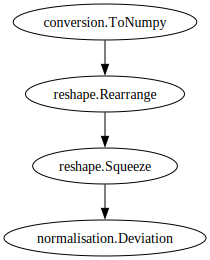

In [26]:
reverse_pipeline

In [27]:
# Wrap the trained model with the data preparation pipeline
model_wrapper = pyearthtools.training.lightning.Predict(
    model,                  # The trained CNN model
    data_preparation_normed # The data preparation pipeline
)

# Initialise the predictor with the model wrapper and reverse pipeline
predictor = pyearthtools.training.predict.Predictor(
    model_wrapper,  # The wrapped model with data preparation steps
    reverse_pipeline # The reverse pipeline to convert predictions back to original space
)

In [28]:
data_preparation_normed[test_start][1]

array([[[ 1.6265482 ,  1.6642686 ,  1.7807953 , ..., -0.41998312,
         -0.05053011, -0.62035227],
        [ 1.6282165 ,  1.6466169 ,  1.755078  , ..., -0.86967456,
         -0.06659667, -0.6387649 ],
        [ 1.6345234 ,  1.6240315 ,  1.6426649 , ..., -1.0400431 ,
         -0.24917367, -0.6859972 ],
        ...,
        [ 1.642726  ,  1.4959918 ,  1.295203  , ..., -0.7554755 ,
         -0.57467616, -0.5757325 ],
        [ 1.6350749 ,  1.5650128 ,  1.506095  , ..., -0.63705313,
         -0.49757466, -0.62132066],
        [ 1.6291701 ,  1.644258  ,  1.6520036 , ..., -0.3815208 ,
         -0.30504227, -0.6222776 ]],

       [[ 0.37331304,  0.04814345, -0.97122186, ..., -0.3308119 ,
         -1.1623396 ,  0.06890745],
        [ 0.39981708,  0.11974857, -0.916135  , ..., -0.6844403 ,
         -1.2961906 ,  0.08652025],
        [ 0.42725852,  0.1846136 , -0.8319019 , ..., -0.95627266,
         -1.4884118 ,  0.085261  ],
        ...,
        [ 0.24053523,  0.04329998, -0.41543078, ..., -

In [29]:
%%time 

# Define the test split using a date range with 1-hour intervals
test_split = pyearthtools.pipeline.iterators.DateRange(test_start, test_end, interval="6h")

# Initialise lists to store true values and predictions
y_true = []
y_preds = []

# Iterate over the test dates and process each one
for test_date in track(list(test_split)):
    # Apply the reverse pipeline to get the true values
    y = reverse_pipeline.apply(data_preparation_normed[test_date][1])
    y["time"] = y.time.copy(data=[test_date.datetime64()])
    y_true.append(y)

    # Predict the values using the predictor
    y_pred = predictor.predict(test_date)
    # Add the test date to the predictions
    y_pred["time"] = y_pred.time.copy(data=[test_date.datetime64()])
    y_preds.append(y_pred)

# Concatenate the true values and predictions along the time dimension
y_true = xr.concat(y_true, dim="time")
y_preds = xr.concat(y_preds, dim="time")

Output()

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_R

CPU times: user 2.7 s, sys: 156 ms, total: 2.86 s
Wall time: 2.86 s


In [30]:
y_preds

<xarray.Dataset> Size: 2MB
Dimensions:                 (time: 44, longitude: 64, latitude: 32)
Coordinates:
  * time                    (time) datetime64[ns] 352B 2017-01-01 ... 2017-01...
  * longitude               (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * latitude                (latitude) float64 256B -87.19 -81.56 ... 87.19
Data variables:
    2m_temperature          (time, longitude, latitude) float32 360kB 236.5 ....
    u_component_of_wind850  (time, longitude, latitude) float32 360kB -4.186 ...
    v_component_of_wind850  (time, longitude, latitude) float32 360kB -4.593 ...
    vorticity850            (time, longitude, latitude) float32 360kB -4.668e...
    geopotential850         (time, longitude, latitude) float32 360kB 1.223e+...
Attributes:
    level-dtype:  int64

Text(0.5, 1.05, 'Predictions')

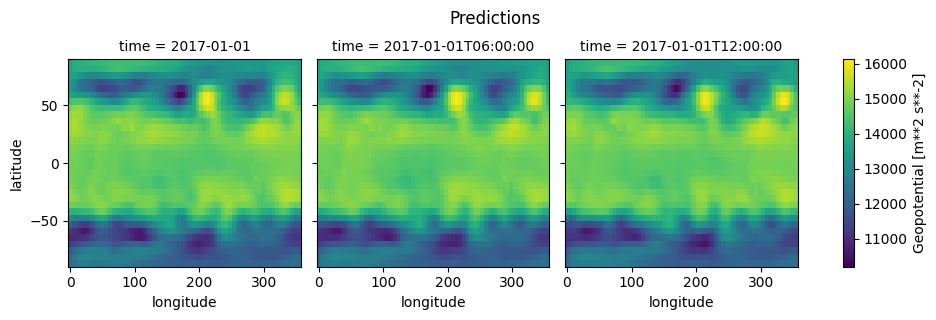

In [31]:
grid = y_preds.isel(time=slice(3))["geopotential850"].plot(x="longitude", y="latitude", col="time")
grid.fig.suptitle("Predictions", y=1.05)

Text(0.5, 1.05, 'Ground truth')

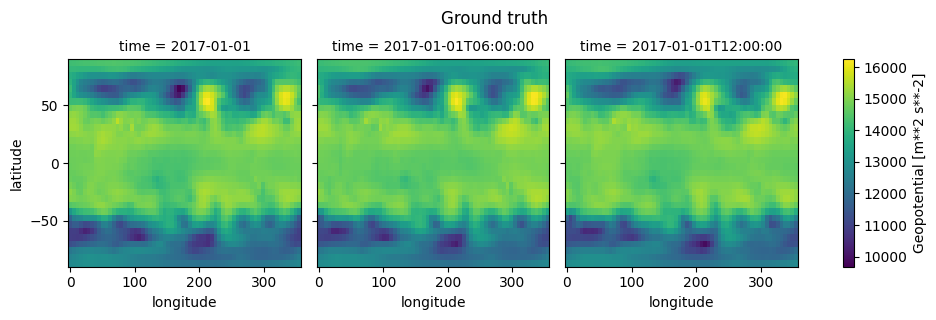

In [32]:
grid = y_true.isel(time=slice(3))["geopotential850"].plot(x="longitude", y="latitude", col="time")
grid.fig.suptitle("Ground truth", y=1.05)

## Evaluation

In [33]:
mae_score = scores.continuous.mae(
    y_preds, y_true, preserve_dims=["latitude", "longitude"]
)

In [34]:
mae_score

<xarray.Dataset> Size: 42kB
Dimensions:                 (longitude: 64, latitude: 32)
Coordinates:
  * longitude               (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
  * latitude                (latitude) float64 256B -87.19 -81.56 ... 87.19
Data variables:
    2m_temperature          (longitude, latitude) float32 8kB 11.67 ... 5.455
    u_component_of_wind850  (longitude, latitude) float32 8kB 0.8308 ... 3.061
    v_component_of_wind850  (longitude, latitude) float32 8kB 0.5541 ... 5.419
    vorticity850            (longitude, latitude) float32 8kB 4.153e-06 ... 1...
    geopotential850         (longitude, latitude) float32 8kB 525.4 ... 472.6
Attributes:
    level-dtype:  int64

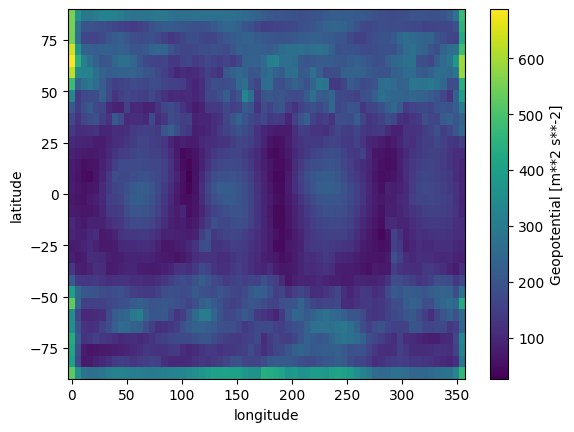

In [35]:
mae_score["geopotential850"].plot(x="longitude", y="latitude")